# Massachusetts Department of Revenue — Tax Compliance Analysis

**Purpose:** Identify non-compliant taxpayers, quantify the tax gap, and generate a
prioritised audit list using statistical methods.

**Audience:** Senior DOR analysts and audit selection committee

**Method:** No machine-learning models are used. All findings rely on descriptive
statistics, z-scores, percentile thresholds, and cross-tabulations that can be
explained and defended in an audit proceeding.

---

## Section 1 — Data Loading & Cleaning

We start by loading the raw dataset, inspecting its shape, and documenting every
cleaning decision so the analysis is fully reproducible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Data path ─────────────────────────────────────────────────────────────────
DATA_PATH = r"C:\Users\Atharva\ma-tax-analytics\data\ma_tax_compliance_data.csv"
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
df_raw = pd.read_csv(r"C:\Users\Atharva\ma-tax-analytics\data\ma_tax_compliance_data.csv")

print(f'Rows loaded  : {len(df_raw):,}')
print(f'Columns      : {df_raw.shape[1]}')
print()
print('Column names:')
for c in df_raw.columns:
    print(f'  {c}')

Rows loaded  : 3,000
Columns      : 19

Column names:
  Taxpayer_ID
  Business_Name
  Tax_Year
  Tax_Type
  Industry
  City
  Reported_Revenue
  Reported_Deductions
  Taxable_Income
  Tax_Paid
  Expected_Tax
  Estimated_Tax_Gap
  Number_of_Employees
  Filing_Status
  Previously_Audited
  Prior_Audit_Result
  Industry_Avg_Revenue
  Revenue_Ratio
  Compliance_Flag


### 1.1 Cleaning Plan

Before touching any data we document what needs to be fixed:

| Step | Action | Reason |
|---|---|---|
| 1 | Standardise column names | Removes spaces/capitalisation inconsistencies |
| 2 | Remove completely empty rows | They add no information |
| 3 | Drop exact duplicates | Avoids double-counting the same filing |
| 4 | Coerce currency columns to `float` | Dollar signs and commas break arithmetic |
| 5 | Title-case text columns | Prevents `'retail'` and `'Retail'` counting as different groups |
| 6 | Derive `Revenue_Ratio` and `Estimated_Tax_Gap` | Core metrics used throughout the analysis |

In [3]:
df = df_raw.copy()

# Step 1 — normalise column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', '_', regex=True)
    .str.replace(r'[^\w]', '', regex=True)
)
# Map common aliases to canonical names
ALIAS = {
    'business_name': 'Business_Name', 'taxpayer_name': 'Business_Name',
    'company_name': 'Business_Name',
    'industry': 'Industry', 'sector': 'Industry',
    'city': 'City', 'municipality': 'City',
    'tax_year': 'Tax_Year', 'year': 'Tax_Year',
    'tax_type': 'Tax_Type',
    'reported_revenue': 'Reported_Revenue', 'revenue': 'Reported_Revenue',
    'industry_avg_revenue': 'Industry_Avg_Revenue', 'expected_revenue': 'Industry_Avg_Revenue',
    'tax_paid': 'Tax_Paid', 'amount_paid': 'Tax_Paid',
    'expected_tax': 'Expected_Tax', 'tax_liability': 'Expected_Tax',
    'estimated_tax_gap': 'Estimated_Tax_Gap', 'tax_gap': 'Estimated_Tax_Gap',
    'revenue_ratio': 'Revenue_Ratio',
    'filing_status': 'Filing_Status',
    'compliance_flag': 'Compliance_Flag',
    'previously_audited': 'Previously_Audited',
    'prior_audit_result': 'Prior_Audit_Result',
}
df.rename(columns=ALIAS, inplace=True)

# Step 2 — remove fully empty rows
before = len(df)
df.dropna(how='all', inplace=True)
print(f'Empty rows removed    : {before - len(df):,}')

# Step 3 — drop exact duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicate rows removed: {before - len(df):,}')

# Step 4 — coerce numeric columns
NUMERIC = ['Reported_Revenue', 'Industry_Avg_Revenue', 'Tax_Paid',
           'Expected_Tax', 'Estimated_Tax_Gap', 'Revenue_Ratio']
for col in NUMERIC:
    if col in df.columns:
        df[col] = (
            df[col].astype(str)
            .str.replace(r'[\$,\s]', '', regex=True)
            .replace('nan', np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 5 — title-case text columns
TEXT = ['Industry', 'City', 'Tax_Type', 'Filing_Status',
        'Compliance_Flag', 'Previously_Audited', 'Prior_Audit_Result']
for col in TEXT:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().replace({'nan': np.nan})
        df[col] = df[col].str.title()

# Step 6 — derive Revenue_Ratio and Estimated_Tax_Gap
if 'Revenue_Ratio' not in df.columns:
    if {'Reported_Revenue', 'Industry_Avg_Revenue'}.issubset(df.columns):
        df['Revenue_Ratio'] = df['Reported_Revenue'] / df['Industry_Avg_Revenue'].replace(0, np.nan)

if 'Estimated_Tax_Gap' not in df.columns:
    if {'Expected_Tax', 'Tax_Paid'}.issubset(df.columns):
        df['Estimated_Tax_Gap'] = (df['Expected_Tax'] - df['Tax_Paid']).clip(lower=0)

df.reset_index(drop=True, inplace=True)
print(f'\nFinal row count: {len(df):,}')
print(f'Final columns  : {list(df.columns)}')

Empty rows removed    : 0
Duplicate rows removed: 0

Final row count: 3,000
Final columns  : ['taxpayer_id', 'Business_Name', 'Tax_Year', 'Tax_Type', 'Industry', 'City', 'Reported_Revenue', 'reported_deductions', 'taxable_income', 'Tax_Paid', 'Expected_Tax', 'Estimated_Tax_Gap', 'number_of_employees', 'Filing_Status', 'Previously_Audited', 'Prior_Audit_Result', 'Industry_Avg_Revenue', 'Revenue_Ratio', 'Compliance_Flag']


In [4]:
print('=== df.info() ===')
df.info()
print()
print('=== Missing value counts ===')
print(df.isnull().sum().to_string())

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   taxpayer_id           3000 non-null   object 
 1   Business_Name         3000 non-null   object 
 2   Tax_Year              3000 non-null   int64  
 3   Tax_Type              3000 non-null   object 
 4   Industry              3000 non-null   object 
 5   City                  3000 non-null   object 
 6   Reported_Revenue      3000 non-null   float64
 7   reported_deductions   3000 non-null   float64
 8   taxable_income        3000 non-null   float64
 9   Tax_Paid              3000 non-null   float64
 10  Expected_Tax          3000 non-null   float64
 11  Estimated_Tax_Gap     3000 non-null   float64
 12  number_of_employees   3000 non-null   int64  
 13  Filing_Status         3000 non-null   object 
 14  Previously_Audited    3000 non-null   object 
 15  Pri

In [5]:
print('=== Descriptive Statistics (numeric columns) ===')
numeric_cols = [c for c in ['Reported_Revenue', 'Industry_Avg_Revenue', 'Tax_Paid',
                            'Expected_Tax', 'Estimated_Tax_Gap', 'Revenue_Ratio']
               if c in df.columns]
df[numeric_cols].describe().applymap(lambda x: f'{x:,.2f}')

=== Descriptive Statistics (numeric columns) ===


,Reported_Revenue,Industry_Avg_Revenue,Tax_Paid,Expected_Tax,Estimated_Tax_Gap,Revenue_Ratio
count,"3,000.00","3,000.00","3,000.00","3,000.00","3,000.00","3,000.00"
mean,"581,146.76","700,650.00","33,971.99","44,203.95","11,024.28",0.83
std,"412,546.99","341,971.33","30,384.79","37,130.40","19,152.99",0.40
min,0.00,"300,000.00",0.00,"2,151.73",0.00,0.00
25%,"299,326.05","450,000.00","15,049.06","21,813.71",681.81,0.56
50%,"489,291.18","600,000.00","25,932.48","33,659.46","5,110.20",0.83
75%,"762,004.87","800,000.00","42,886.43","53,517.56","13,423.48",1.12
max,"2,557,890.86","1,500,000.00","305,989.04","507,501.08","349,523.51",2.18


In [6]:
print('=== First 5 rows ===')
df.head()

=== First 5 rows ===


,taxpayer_id,Business_Name,Tax_Year,Tax_Type,Industry,City,Reported_Revenue,reported_deductions,taxable_income,Tax_Paid,Expected_Tax,Estimated_Tax_Gap,number_of_employees,Filing_Status,Previously_Audited,Prior_Audit_Result,Industry_Avg_Revenue,Revenue_Ratio,Compliance_Flag
0,MA-010001,Pioneer Real Estate Enterprise,2022,Income,Hospitality,Boston,418186.90,115130.28,303056.62,17596.11,20115.99,2519.88,4,On Time,No,NaN,350000,1.1948,Compliant
1,MA-010002,Summit Restaurant Partners,2024,Meals,Manufacturing,Chelsea,1812112.67,489514.96,1322597.71,92581.84,106510.57,13928.73,30,On Time,No,NaN,1500000,1.2081,Compliant
2,MA-010003,Colonial Auto Repair Partners,2022,Meals,Professional Services,Boston,443837.70,169931.46,273906.24,19173.44,24991.69,5818.25,4,On Time,No,NaN,500000,0.8877,Compliant
3,MA-010004,Colonial Auto Repair Holdings,2024,Income,Professional Services,Boston,804582.55,138875.76,665706.79,77615.05,66237.92,0.00,13,On Time,No,NaN,500000,1.6092,Compliant
4,MA-010005,Harbor Healthcare Inc,2024,Sales/Use,Healthcare,Chelsea,1009064.41,342492.14,666572.27,41660.77,43698.01,2037.24,15,On Time,No,NaN,1200000,0.8409,Compliant


---
## Section 2 — Statistical Analysis

With clean data in hand, we examine the distribution of key variables and test
whether the relationships we expect to see (e.g. higher revenue → higher tax paid)
actually hold in this dataset.

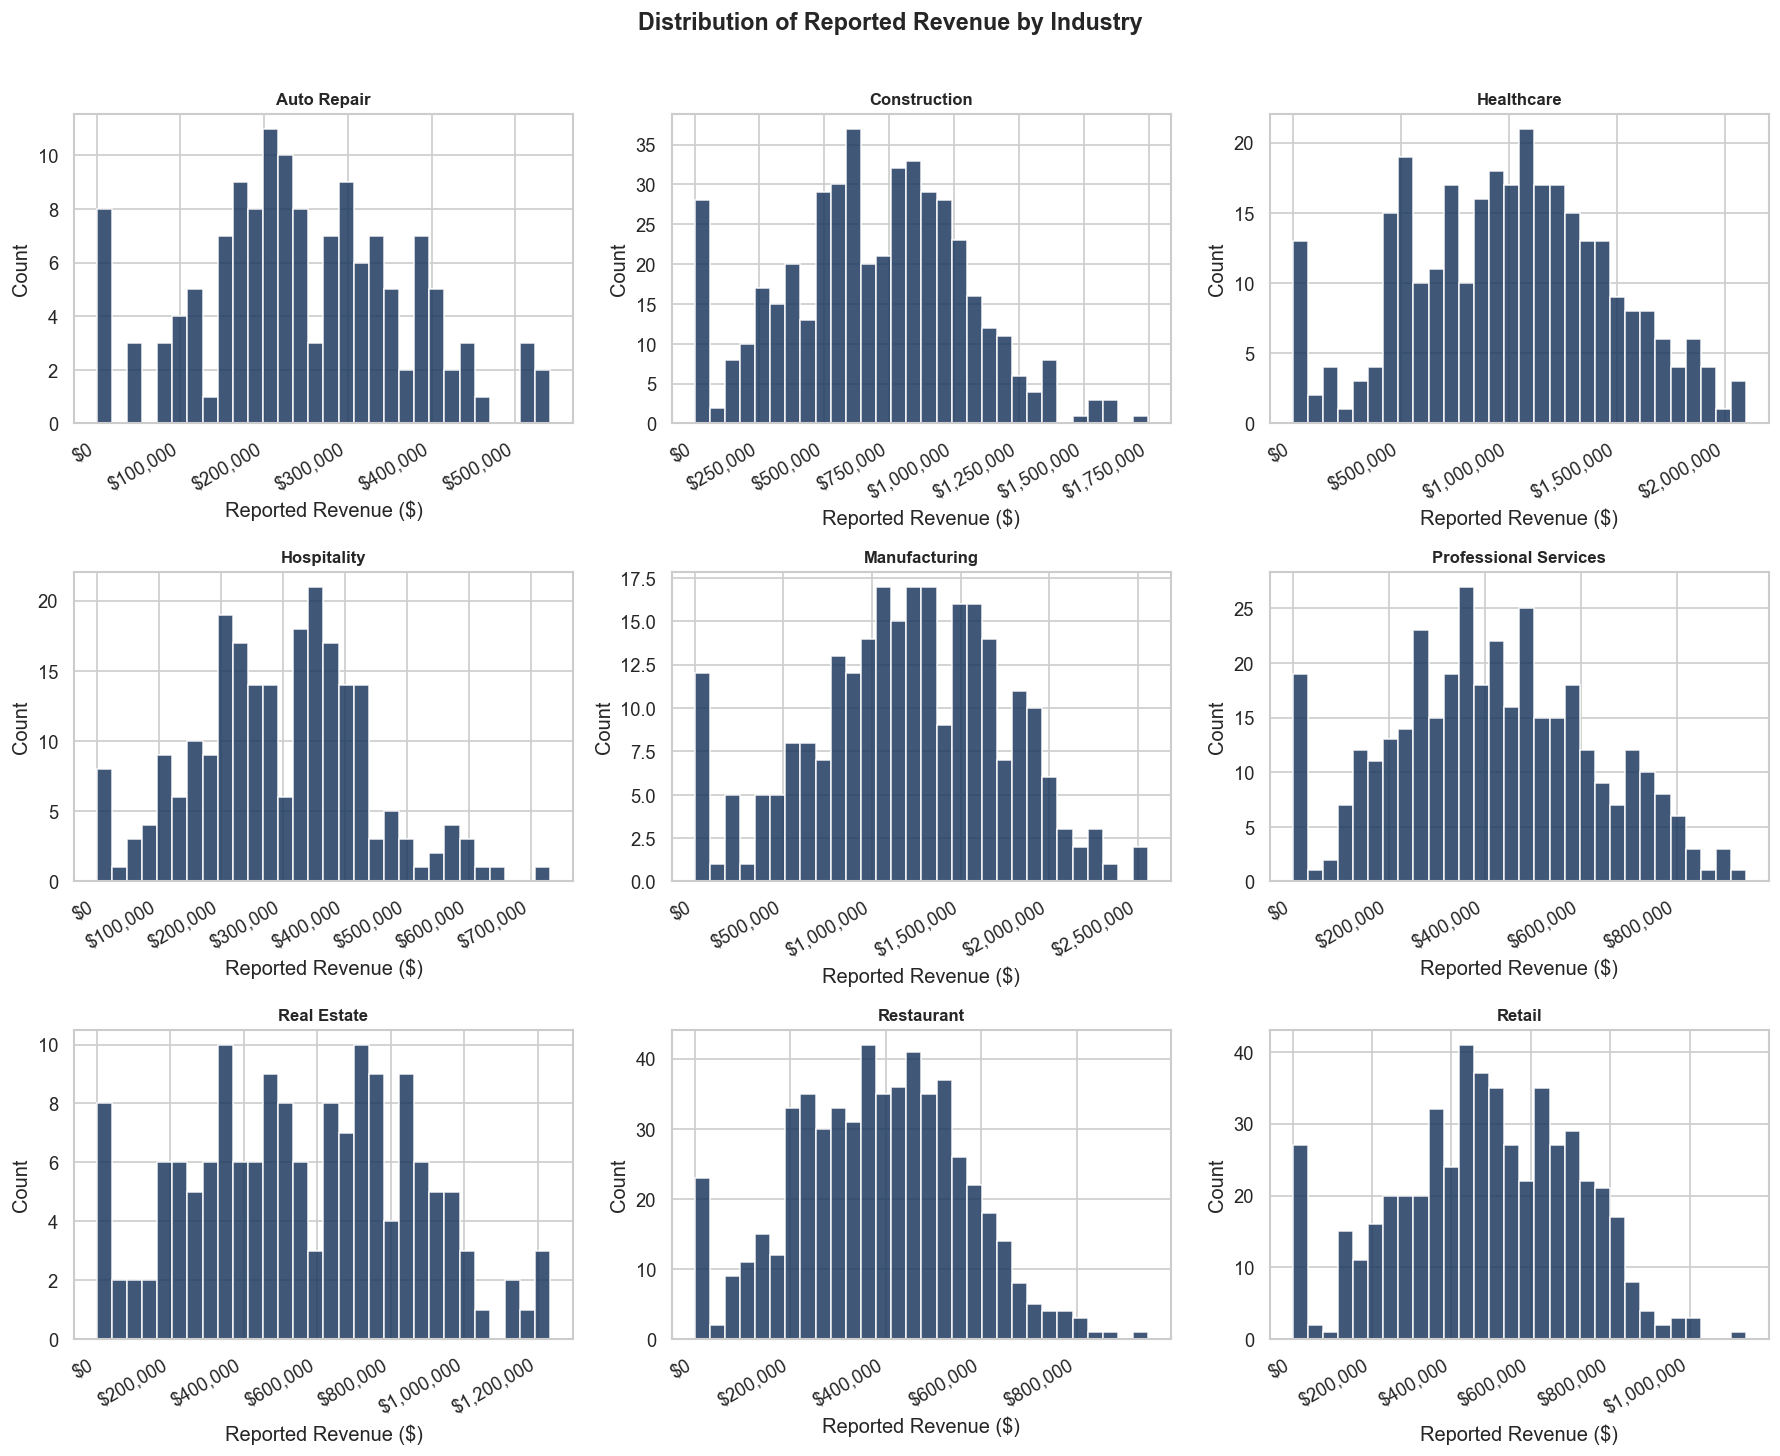

In [7]:
# ── Revenue distribution by industry ─────────────────────────────────────────
if 'Reported_Revenue' in df.columns and 'Industry' in df.columns:
    industries = df['Industry'].dropna().unique()
    n_cols = 3
    n_rows = -(-len(industries) // n_cols)   # ceiling division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for i, ind in enumerate(sorted(industries)):
        data = df[df['Industry'] == ind]['Reported_Revenue'].dropna()
        axes[i].hist(data, bins=30, color='#1e3a5f', edgecolor='white', alpha=0.85)
        axes[i].set_title(ind, fontsize=10, fontweight='bold')
        axes[i].set_xlabel('Reported Revenue ($)')
        axes[i].set_ylabel('Count')
        axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
        plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=30, ha='right')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Distribution of Reported Revenue by Industry', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Reported_Revenue or Industry column not found.')

**What to look for:** Industries with long right tails have a small number of very
large businesses that can skew averages. If the bulk of businesses cluster near
zero while a few report very high revenues, the median is a better benchmark than
the mean for setting audit thresholds.

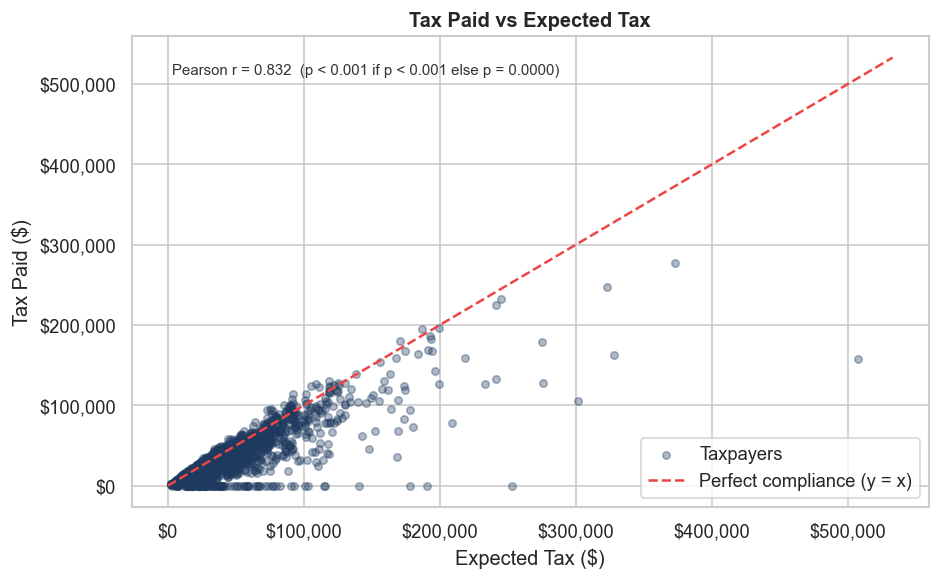

Pearson correlation: 0.8319  |  p-value: 0.0000e+00
Points BELOW the red line are paying less than expected — prime audit candidates.


In [8]:
# ── Tax Paid vs Expected Tax — scatter + regression line ─────────────────────
if {'Tax_Paid', 'Expected_Tax'}.issubset(df.columns):
    sample = df[['Tax_Paid', 'Expected_Tax']].dropna().sample(
        min(2000, len(df)), random_state=42
    )
    corr, pval = stats.pearsonr(sample['Tax_Paid'], sample['Expected_Tax'])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(sample['Expected_Tax'], sample['Tax_Paid'],
               alpha=0.35, s=20, color='#1e3a5f', label='Taxpayers')

    # Perfect-compliance line
    lim = max(sample['Expected_Tax'].max(), sample['Tax_Paid'].max()) * 1.05
    ax.plot([0, lim], [0, lim], '--', color='#ef4444', lw=1.5, label='Perfect compliance (y = x)')

    ax.set_xlabel('Expected Tax ($)')
    ax.set_ylabel('Tax Paid ($)')
    ax.set_title('Tax Paid vs Expected Tax', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend()
    ax.text(0.05, 0.92, f'Pearson r = {corr:.3f}  (p < 0.001 if p < 0.001 else p = {pval:.4f})',
            transform=ax.transAxes, fontsize=9, color='#333')
    plt.tight_layout()
    plt.show()

    print(f'Pearson correlation: {corr:.4f}  |  p-value: {pval:.4e}')
    print('Points BELOW the red line are paying less than expected — prime audit candidates.')
else:
    print('Tax_Paid or Expected_Tax column not found.')

Filing Status breakdown:
  On Time               1,974  (65.8%)
  Late                    447  (14.9%)
  Not Filed               345  (11.5%)
  Amended                 234  (7.8%)


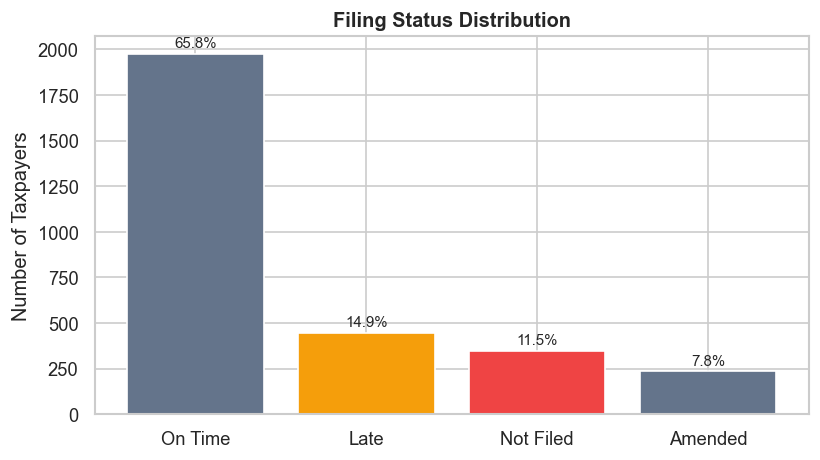

In [9]:
# ── Filing Status distribution ────────────────────────────────────────────────
if 'Filing_Status' in df.columns:
    fs_counts = df['Filing_Status'].value_counts()
    fs_pct    = df['Filing_Status'].value_counts(normalize=True) * 100

    print('Filing Status breakdown:')
    for status in fs_counts.index:
        print(f'  {status:<20} {fs_counts[status]:>6,}  ({fs_pct[status]:.1f}%)')

    palette = {'Filed': '#22c55e', 'Late': '#f59e0b', 'Not Filed': '#ef4444'}
    colors  = [palette.get(s, '#64748b') for s in fs_counts.index]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(fs_counts.index, fs_counts.values, color=colors, edgecolor='white')
    for bar, pct in zip(bars, fs_pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + fs_counts.max() * 0.01,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title('Filing Status Distribution', fontweight='bold')
    ax.set_ylabel('Number of Taxpayers')
    plt.tight_layout()
    plt.show()
else:
    print('Filing_Status column not found.')

Compliance Flag breakdown:
  Compliant                  1,957  (65.2%)
  Underpaid                    612  (20.4%)
  Suspicious                   291  (9.7%)
  Non-Filer                    140  (4.7%)


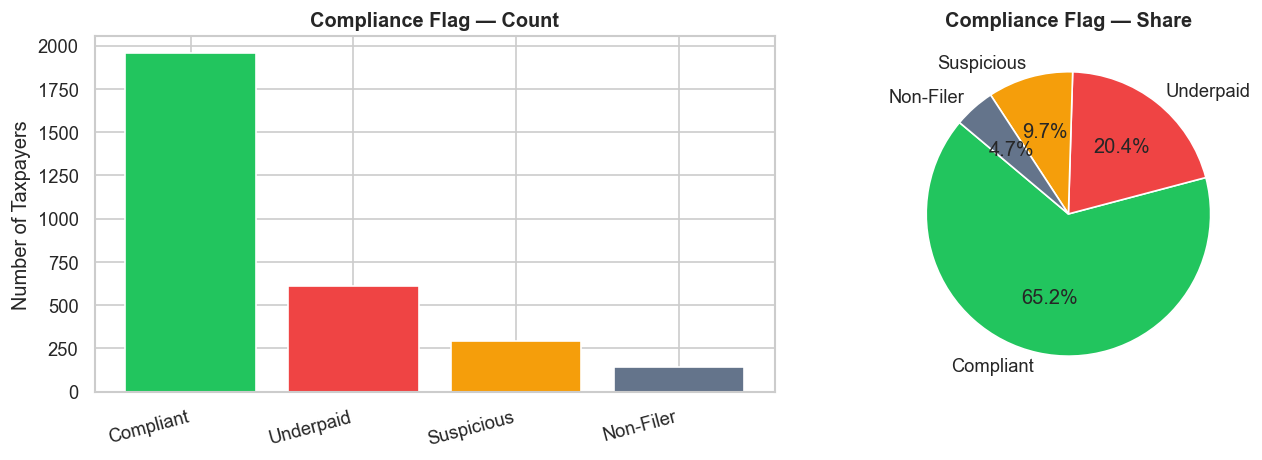

In [10]:
# ── Compliance Flag breakdown ────────────────────────────────────────────────
if 'Compliance_Flag' in df.columns:
    cf_counts = df['Compliance_Flag'].value_counts()
    cf_pct    = df['Compliance_Flag'].value_counts(normalize=True) * 100

    print('Compliance Flag breakdown:')
    for flag in cf_counts.index:
        print(f'  {flag:<25} {cf_counts[flag]:>6,}  ({cf_pct[flag]:.1f}%)')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Bar chart
    ax1.bar(cf_counts.index, cf_counts.values, color=['#22c55e', '#ef4444', '#f59e0b', '#64748b'][:len(cf_counts)])
    ax1.set_title('Compliance Flag — Count', fontweight='bold')
    ax1.set_ylabel('Number of Taxpayers')
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=15, ha='right')

    # Pie chart
    wedge_colors = ['#22c55e', '#ef4444', '#f59e0b', '#64748b'][:len(cf_counts)]
    ax2.pie(cf_counts.values, labels=cf_counts.index, autopct='%1.1f%%',
            colors=wedge_colors, startangle=140)
    ax2.set_title('Compliance Flag — Share', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('Compliance_Flag column not found.')

---
## Section 3 — Data Mining: Finding Patterns

We now move beyond individual variables and look for **combinations** that predict
non-compliance. The key questions are:

1. Which industries under-report the most?
2. Which cities lose the most revenue to the tax gap?
3. Are late filers also more likely to underpay?
4. Do repeat offenders (previously audited, still non-compliant) cluster in certain industries?

Revenue Ratio by Industry (sorted lowest → most suspicious):
                       Mean Ratio  Median Ratio  Std Dev  Count
Industry                                                       
Real Estate                 0.804         0.788    0.425    158
Auto Repair                 0.821         0.789    0.412    139
Professional Services       0.832         0.819    0.421    364
Retail                      0.809         0.819    0.378    522
Manufacturing               0.797         0.824    0.367    257
Hospitality                 0.839         0.839    0.390    228
Healthcare                  0.834         0.843    0.391    305
Restaurant                  0.850         0.858    0.395    567
Construction                0.867         0.878    0.440    460


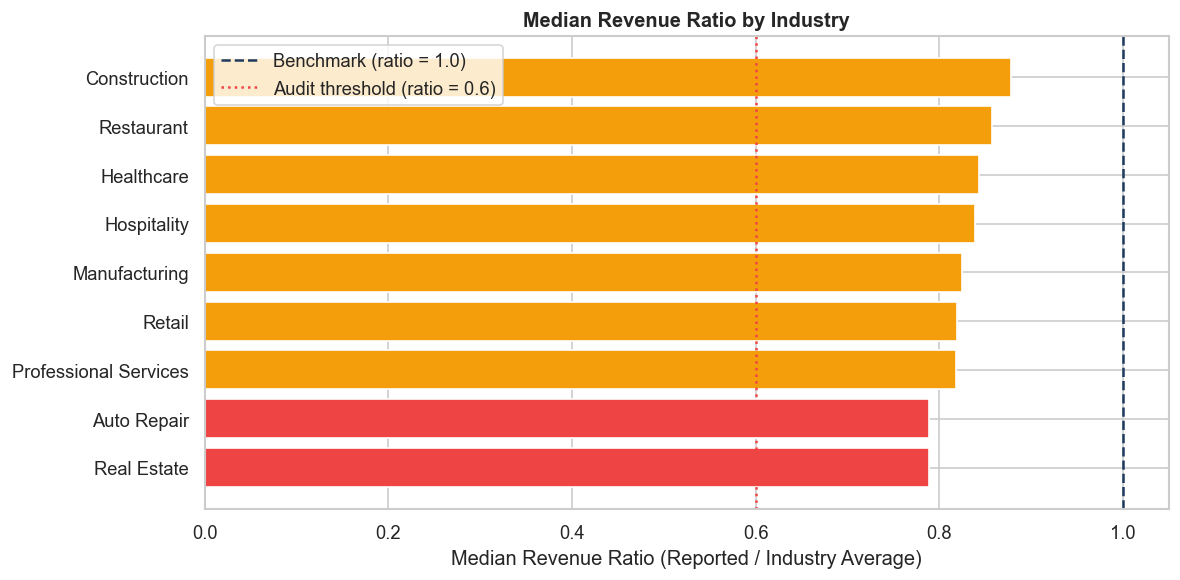


Red bars = industries where the typical business reports < 80% of industry average.


In [11]:
# ── Revenue_Ratio by industry — who under-reports most? ──────────────────────
if 'Revenue_Ratio' in df.columns and 'Industry' in df.columns:
    rr_by_ind = (
        df.groupby('Industry')['Revenue_Ratio']
        .agg(['mean', 'median', 'std', 'count'])
        .rename(columns={'mean': 'Mean Ratio', 'median': 'Median Ratio',
                         'std': 'Std Dev', 'count': 'Count'})
        .sort_values('Median Ratio')
    )
    print('Revenue Ratio by Industry (sorted lowest → most suspicious):')
    print(rr_by_ind.to_string(float_format='{:.3f}'.format))

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#ef4444' if v < 0.8 else '#f59e0b' if v < 1.0 else '#22c55e'
              for v in rr_by_ind['Median Ratio']]
    ax.barh(rr_by_ind.index, rr_by_ind['Median Ratio'], color=colors, edgecolor='white')
    ax.axvline(1.0, color='#1e3a5f', linestyle='--', lw=1.5, label='Benchmark (ratio = 1.0)')
    ax.axvline(0.6, color='#ef4444', linestyle=':', lw=1.5, label='Audit threshold (ratio = 0.6)')
    ax.set_title('Median Revenue Ratio by Industry', fontweight='bold')
    ax.set_xlabel('Median Revenue Ratio (Reported / Industry Average)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print('\nRed bars = industries where the typical business reports < 80% of industry average.')
else:
    print('Revenue_Ratio or Industry column not found.')

Top 15 cities by total estimated tax gap:
              Total_Gap Median_Gap  Cases
City                                     
Boston       $9,044,733     $5,254    777
Worcester    $4,283,571     $4,434    369
Springfield  $3,310,521     $6,563    301
Cambridge    $2,261,220     $5,172    201
New Bedford  $2,234,793     $6,465    173
Chelsea      $2,069,112     $4,473    220
Lowell       $1,937,387     $3,355    204
Fall River   $1,806,373     $4,746    188
Somerville   $1,804,806     $6,276    148
Quincy       $1,509,231     $6,007    141
Lynn         $1,489,750     $4,533    132
Brockton     $1,321,346     $5,001    146


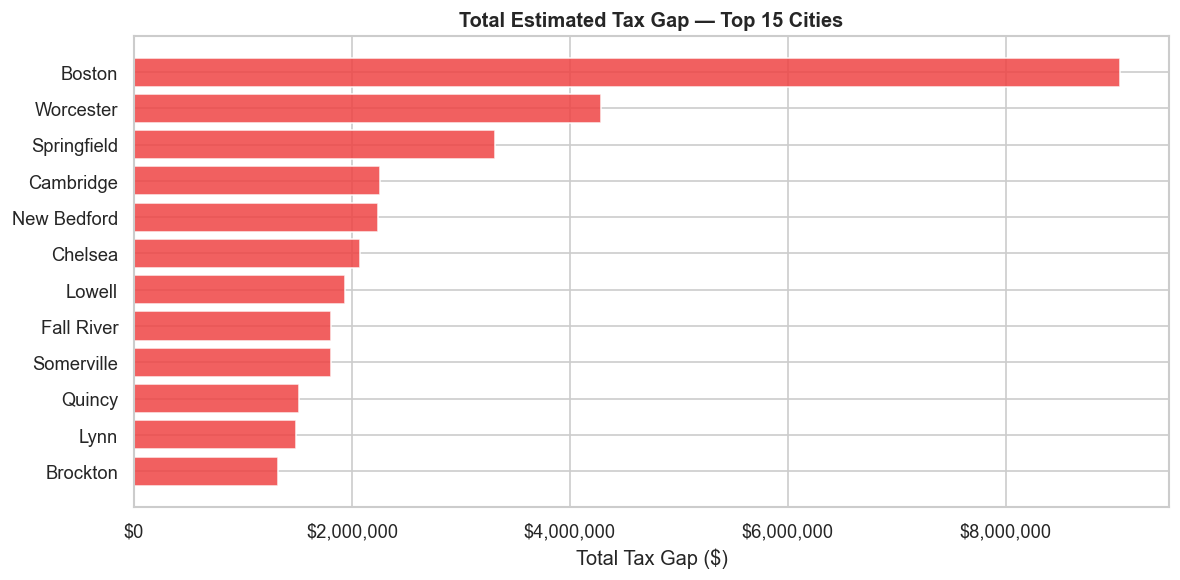

In [12]:
# ── Tax gap by city ──────────────────────────────────────────────────────────
if 'City' in df.columns and 'Estimated_Tax_Gap' in df.columns:
    gap_city = (
        df.groupby('City')['Estimated_Tax_Gap']
        .agg(Total_Gap='sum', Median_Gap='median', Cases='count')
        .sort_values('Total_Gap', ascending=False)
        .head(15)
    )
    print('Top 15 cities by total estimated tax gap:')
    gap_city['Total_Gap']  = gap_city['Total_Gap'].map('${:,.0f}'.format)
    gap_city['Median_Gap'] = gap_city['Median_Gap'].map('${:,.0f}'.format)
    print(gap_city.to_string())

    gap_city_plot = (
        df.groupby('City')['Estimated_Tax_Gap']
        .sum().sort_values(ascending=False).head(15)
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(gap_city_plot.index[::-1], gap_city_plot.values[::-1],
            color='#ef4444', edgecolor='white', alpha=0.85)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_title('Total Estimated Tax Gap — Top 15 Cities', fontweight='bold')
    ax.set_xlabel('Total Tax Gap ($)')
    plt.tight_layout()
    plt.show()
else:
    print('City or Estimated_Tax_Gap column not found.')

Tax Gap by Tax Type:
                  Total_Gap  Cases  Avg_Gap_Per_Case
Tax_Type                                            
Income           9596026.13    930      10318.307667
Corporate        8059780.78    742      10862.238248
Special Fuels    5410277.27    150      36068.515133
Sales/Use        4740649.02    594       7980.890606
Meals            3511940.13    354       9920.734831
Rooms Occupancy  1754169.99    230       7626.826043


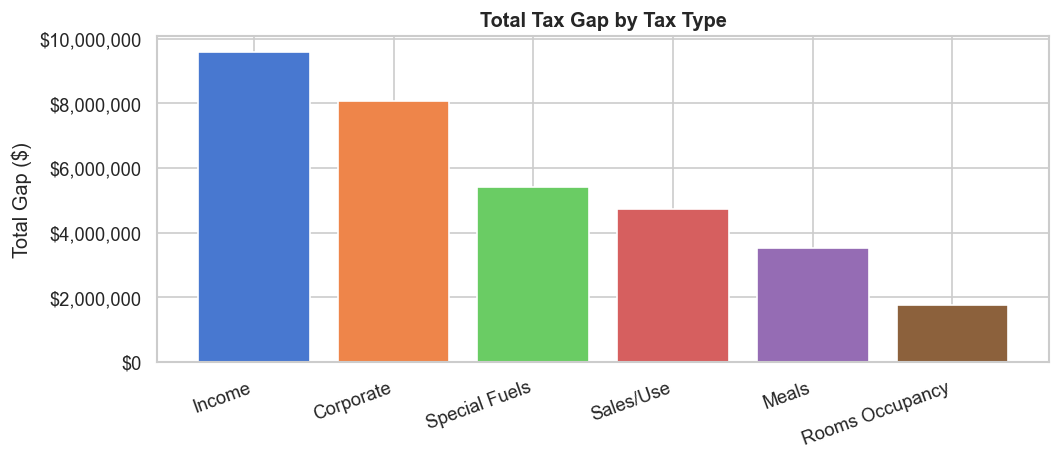

In [13]:
# ── Tax gap by tax type ──────────────────────────────────────────────────────
if 'Tax_Type' in df.columns and 'Estimated_Tax_Gap' in df.columns:
    gap_type = (
        df.groupby('Tax_Type')['Estimated_Tax_Gap']
        .agg(Total_Gap='sum', Cases='count')
        .sort_values('Total_Gap', ascending=False)
    )
    gap_type['Avg_Gap_Per_Case'] = (
        df.groupby('Tax_Type')['Estimated_Tax_Gap'].mean()
    )
    print('Tax Gap by Tax Type:')
    print(gap_type.to_string())

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(gap_type.index, gap_type['Total_Gap'],
           color=sns.color_palette('muted', len(gap_type)), edgecolor='white')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_title('Total Tax Gap by Tax Type', fontweight='bold')
    ax.set_ylabel('Total Gap ($)')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Tax_Type or Estimated_Tax_Gap column not found.')

Counts — Industry vs Compliance Flag:
Compliance_Flag        Compliant  Non-Filer  Suspicious  Underpaid   All
Industry                                                                
Auto Repair                   93          8          10         28   139
Construction                 297         25          38        100   460
Healthcare                   200         12          27         66   305
Hospitality                  158          8          19         43   228
Manufacturing                162         12          30         53   257
Professional Services        241         19          32         72   364
Real Estate                   96          7          24         31   158
Restaurant                   365         23          60        119   567
Retail                       345         26          51        100   522
All                         1957        140         291        612  3000

Row percentages:
Compliance_Flag        Compliant  Non-Filer  Suspicious  Underpaid
I

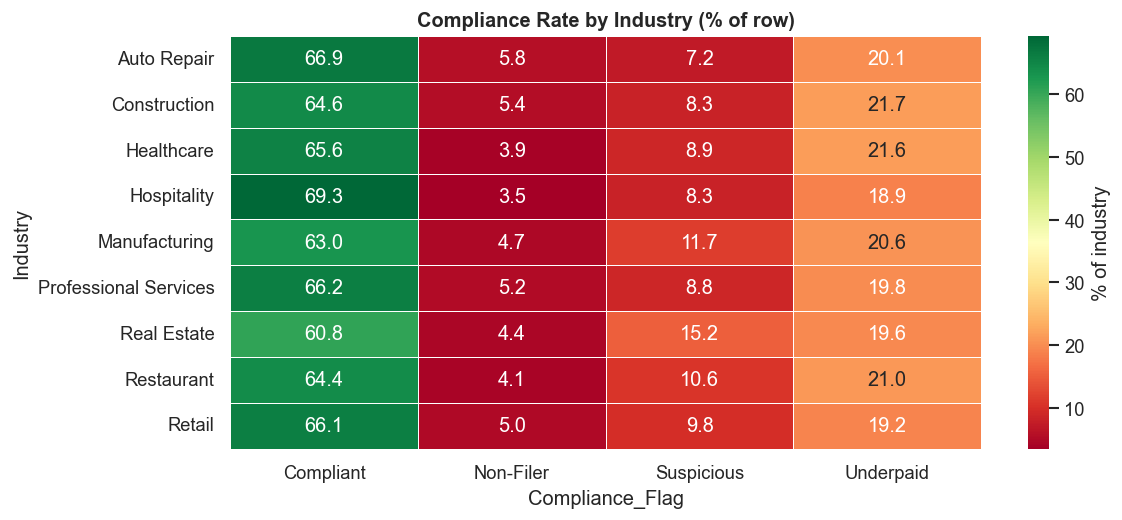

In [14]:
# ── Cross-tab: Industry vs Compliance_Flag ────────────────────────────────────
if 'Industry' in df.columns and 'Compliance_Flag' in df.columns:
    ct = pd.crosstab(df['Industry'], df['Compliance_Flag'], margins=True)
    ct_pct = pd.crosstab(df['Industry'], df['Compliance_Flag'], normalize='index') * 100

    print('Counts — Industry vs Compliance Flag:')
    print(ct.to_string())
    print('\nRow percentages:')
    print(ct_pct.round(1).to_string())

    # Chi-squared test
    ct_no_margins = pd.crosstab(df['Industry'], df['Compliance_Flag'])
    chi2, pval, dof, _ = stats.chi2_contingency(ct_no_margins)
    print(f'\nChi-squared test: χ²={chi2:.2f}, df={dof}, p={pval:.4e}')
    if pval < 0.05:
        print('→ Compliance rates differ significantly across industries (p < 0.05).')
    else:
        print('→ No statistically significant difference in compliance rates by industry.')

    # Heatmap
    fig, ax = plt.subplots(figsize=(10, max(4, len(ct_pct) * 0.5)))
    sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
                linewidths=0.5, cbar_kws={'label': '% of industry'})
    ax.set_title('Compliance Rate by Industry (% of row)', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Industry or Compliance_Flag column not found.')

Compliance rate by Filing Status (%):
Compliance_Flag  Compliant  Non-Filer  Suspicious  Underpaid
Filing_Status                                               
Amended               72.2        0.0         7.7       20.1
Late                  69.1        0.0        10.5       20.4
Not Filed             37.4       40.6         7.2       14.8
On Time               68.4        0.0        10.2       21.4


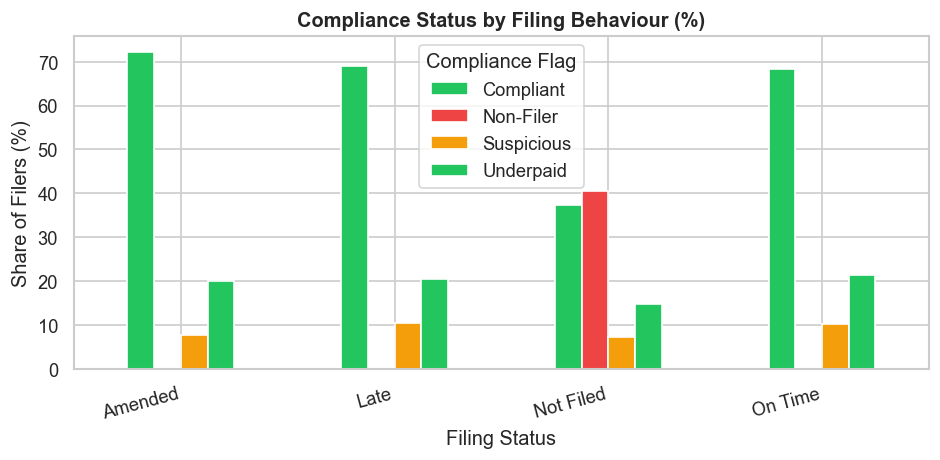


If Late filers have a higher Non-Compliant share, late filing is a risk signal.


In [15]:
# ── Late filers vs compliance ─────────────────────────────────────────────────
if 'Filing_Status' in df.columns and 'Compliance_Flag' in df.columns:
    late_ct = pd.crosstab(df['Filing_Status'], df['Compliance_Flag'], normalize='index') * 100
    print('Compliance rate by Filing Status (%):')
    print(late_ct.round(1).to_string())

    # Bar chart
    ax = late_ct.plot(kind='bar', figsize=(8, 4), edgecolor='white',
                      color=['#22c55e', '#ef4444', '#f59e0b'][:late_ct.shape[1]])
    ax.set_title('Compliance Status by Filing Behaviour (%)', fontweight='bold')
    ax.set_ylabel('Share of Filers (%)')
    ax.set_xlabel('Filing Status')
    ax.legend(title='Compliance Flag')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')
    plt.tight_layout()
    plt.show()
    print('\nIf Late filers have a higher Non-Compliant share, late filing is a risk signal.')
else:
    print('Filing_Status or Compliance_Flag column not found.')

Repeat offenders (previously audited AND still non-compliant): 23
  = 0.8% of all taxpayers

Repeat offenders by industry:
Industry
Professional Services    6
Restaurant               6
Healthcare               3
Retail                   3
Manufacturing            2
Construction             1
Hospitality              1
Real Estate              1


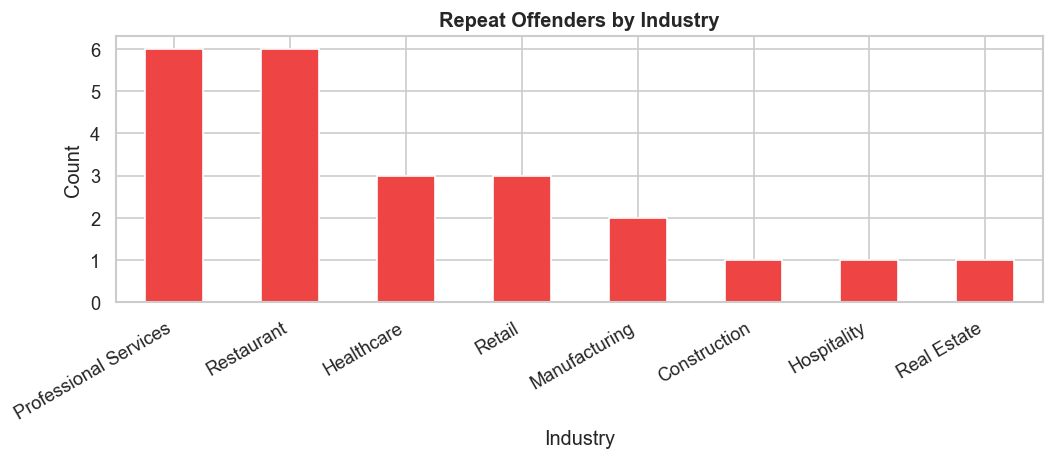

In [16]:
# ── Repeat offenders ─────────────────────────────────────────────────────────
if 'Previously_Audited' in df.columns and 'Compliance_Flag' in df.columns:
    repeat = df[
        (df['Previously_Audited'].str.lower().str.contains('yes', na=False)) &
        (df['Compliance_Flag'].str.lower().str.contains('non', na=False))
    ]
    print(f'Repeat offenders (previously audited AND still non-compliant): {len(repeat):,}')
    print(f'  = {len(repeat)/len(df)*100:.1f}% of all taxpayers\n')

    if 'Industry' in repeat.columns:
        print('Repeat offenders by industry:')
        print(repeat['Industry'].value_counts().to_string())

        fig, ax = plt.subplots(figsize=(9, 4))
        repeat['Industry'].value_counts().plot(
            kind='bar', ax=ax, color='#ef4444', edgecolor='white'
        )
        ax.set_title('Repeat Offenders by Industry', fontweight='bold')
        ax.set_ylabel('Count')
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
        plt.tight_layout()
        plt.show()
else:
    print('Previously_Audited or Compliance_Flag column not found.')

---
## Section 4 — Audit Selection Logic

### How the Risk Score Works

We combine four statistical signals into a single **Risk Score from 0 to 100**.
A higher score means the taxpayer shows more characteristics associated with
non-compliance.  The score is *relative* — it compares each business to others in
the same industry, so a restaurant is never unfairly penalised for earning less
than a technology company.

| Signal | Max Points | Description |
|---|---|---|
| Revenue under-reporting | 35 | Z-score of Revenue_Ratio within industry — low ratio = higher risk |
| Absolute tax gap | 30 | Large gaps represent large recoverable amounts |
| Filing behaviour | 20 | Not filed = 20 pts, Late = 15 pts, Filed = 0 pts |
| Prior audit history | 15 | Prior fraud finding = 15 pts, underpayment = 10 pts |

In [17]:
# ── Z-scores for Revenue_Ratio within each industry ──────────────────────────
df_risk = df.copy()

if 'Revenue_Ratio' in df_risk.columns and 'Industry' in df_risk.columns:
    def _industry_zscore(group):
        s = group['Revenue_Ratio'].fillna(group['Revenue_Ratio'].median())
        if s.std() == 0:
            group['RR_ZScore'] = 0.0
        else:
            group['RR_ZScore'] = stats.zscore(s)
        return group

    df_risk = df_risk.groupby('Industry', group_keys=False).apply(_industry_zscore)
    # Invert: low ratio (under-reporter) → high z-risk
    df_risk['RR_ZScore'] = -df_risk['RR_ZScore']
    print('Z-score column added. Sample:')
    print(df_risk[['Industry', 'Revenue_Ratio', 'RR_ZScore']].head(10).to_string(index=False))
else:
    df_risk['RR_ZScore'] = 0.0
    print('Revenue_Ratio or Industry not available — z-score set to 0.')

Z-score column added. Sample:
             Industry  Revenue_Ratio  RR_ZScore
          Hospitality         1.1948  -0.916214
        Manufacturing         1.2081  -1.122142
Professional Services         0.8877  -0.132959
Professional Services         1.6092  -1.851104
           Healthcare         0.8409  -0.018943
               Retail         0.8578  -0.128083
           Healthcare         1.0470  -0.546767
         Construction         0.3605   1.151956
               Retail         0.4929   0.838567
Professional Services         0.5553   0.658602


In [18]:
# ── Individual audit flags ────────────────────────────────────────────────────

# Flag 1: Revenue Ratio < 0.6  (reporting less than 60% of industry average)
if 'Revenue_Ratio' in df_risk.columns:
    df_risk['Flag_LowRevRatio'] = (df_risk['Revenue_Ratio'] < 0.6).astype(int)
else:
    df_risk['Flag_LowRevRatio'] = 0

# Flag 2: Tax gap above industry median
if 'Estimated_Tax_Gap' in df_risk.columns and 'Industry' in df_risk.columns:
    ind_median_gap = df_risk.groupby('Industry')['Estimated_Tax_Gap'].transform('median')
    df_risk['Flag_HighGap'] = (df_risk['Estimated_Tax_Gap'] > ind_median_gap).astype(int)
else:
    df_risk['Flag_HighGap'] = 0

# Flag 3: Non-filer or late filer
if 'Filing_Status' in df_risk.columns:
    df_risk['Flag_LateOrNonFiler'] = df_risk['Filing_Status'].str.lower().apply(
        lambda s: 1 if ('not' in str(s) or 'late' in str(s)) else 0
    )
else:
    df_risk['Flag_LateOrNonFiler'] = 0

# Flag 4: Repeat offender
if 'Previously_Audited' in df_risk.columns and 'Compliance_Flag' in df_risk.columns:
    df_risk['Flag_RepeatOffender'] = (
        (df_risk['Previously_Audited'].str.lower().str.contains('yes', na=False)) &
        (df_risk['Compliance_Flag'].str.lower().str.contains('non', na=False))
    ).astype(int)
else:
    df_risk['Flag_RepeatOffender'] = 0

flag_cols = ['Flag_LowRevRatio', 'Flag_HighGap', 'Flag_LateOrNonFiler', 'Flag_RepeatOffender']
print('Flag summary:')
for f in flag_cols:
    n = df_risk[f].sum()
    print(f'  {f:<28} {n:,}  ({n/len(df_risk)*100:.1f}%)')

Flag summary:
  Flag_LowRevRatio             852  (28.4%)
  Flag_HighGap                 1,498  (49.9%)
  Flag_LateOrNonFiler          792  (26.4%)
  Flag_RepeatOffender          23  (0.8%)


Risk Score distribution:
count    3000.0
mean       28.8
std        14.3
min         0.0
25%        18.7
50%        25.7
75%        35.3
max        92.1


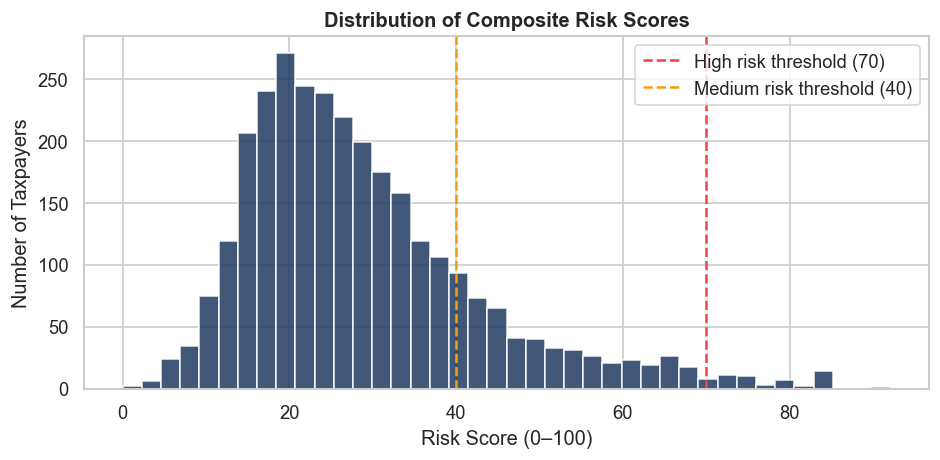

In [19]:
# ── Build composite Risk Score (0-100) ───────────────────────────────────────

# Signal 1: revenue z-score → 35 pts
zs = df_risk['RR_ZScore'].clip(-3, 3)
zs_min, zs_max = zs.min(), zs.max()
if zs_max > zs_min:
    sig_rev = ((zs - zs_min) / (zs_max - zs_min)) * 35
else:
    sig_rev = pd.Series(0.0, index=df_risk.index)

# Signal 2: absolute tax gap → 30 pts
if 'Estimated_Tax_Gap' in df_risk.columns:
    gap = df_risk['Estimated_Tax_Gap'].clip(lower=0).fillna(0)
    g99 = gap.quantile(0.99)
    sig_gap = (gap.clip(upper=g99) / g99 * 30) if g99 > 0 else pd.Series(0.0, index=df_risk.index)
else:
    sig_gap = pd.Series(0.0, index=df_risk.index)

# Signal 3: filing status → 20 pts
sig_file = df_risk['Flag_LateOrNonFiler'].map({1: 20, 0: 0}).fillna(0).astype(float)
# Nuance: not-filed gets full 20, late gets 15
if 'Filing_Status' in df_risk.columns:
    not_filed_mask = df_risk['Filing_Status'].str.lower().str.contains('not', na=False)
    late_mask      = df_risk['Filing_Status'].str.lower().str.contains('late', na=False)
    sig_file = pd.Series(0.0, index=df_risk.index)
    sig_file[not_filed_mask] = 20
    sig_file[late_mask]       = 15

# Signal 4: prior audit result → 15 pts
if 'Prior_Audit_Result' in df_risk.columns:
    par = df_risk['Prior_Audit_Result'].str.lower().fillna('')
    sig_aud = par.map(lambda s: 15 if 'fraud' in s else (10 if 'underpay' in s else 0)).astype(float)
else:
    sig_aud = df_risk['Flag_RepeatOffender'].map({1: 8, 0: 0}).fillna(0).astype(float)

df_risk['Risk_Score'] = (sig_rev + sig_gap + sig_file + sig_aud).clip(0, 100).round(1)

print('Risk Score distribution:')
print(df_risk['Risk_Score'].describe().map('{:.1f}'.format).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_risk['Risk_Score'], bins=40, color='#1e3a5f', edgecolor='white', alpha=0.85)
ax.axvline(70, color='#ef4444', linestyle='--', lw=1.5, label='High risk threshold (70)')
ax.axvline(40, color='#f59e0b', linestyle='--', lw=1.5, label='Medium risk threshold (40)')
ax.set_title('Distribution of Composite Risk Scores', fontweight='bold')
ax.set_xlabel('Risk Score (0–100)')
ax.set_ylabel('Number of Taxpayers')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# ── Top 20 recommended audits ─────────────────────────────────────────────────
display_cols = [c for c in [
    'Business_Name', 'Industry', 'City', 'Tax_Year', 'Tax_Type',
    'Risk_Score', 'Estimated_Tax_Gap', 'Revenue_Ratio',
    'Filing_Status', 'Compliance_Flag', 'Previously_Audited', 'Prior_Audit_Result',
] if c in df_risk.columns]

top20 = df_risk.nlargest(20, 'Risk_Score')[display_cols].copy()

# Format dollar columns for display
if 'Estimated_Tax_Gap' in top20.columns:
    top20['Estimated_Tax_Gap'] = top20['Estimated_Tax_Gap'].map('${:,.0f}'.format)
if 'Revenue_Ratio' in top20.columns:
    top20['Revenue_Ratio'] = top20['Revenue_Ratio'].map('{:.3f}'.format)

top20.index = range(1, 21)
top20.index.name = 'Rank'

print('=== TOP 20 RECOMMENDED AUDIT TARGETS ===')
print(top20.to_string())

# Estimated recovery from top 20
top20_gap = df_risk.nlargest(20, 'Risk_Score')['Estimated_Tax_Gap'].sum() \
            if 'Estimated_Tax_Gap' in df_risk.columns else 0
print(f'\nEstimated recoverable revenue from top 20 audits: ${top20_gap:,.0f}')

top100_gap = df_risk.nlargest(100, 'Risk_Score')['Estimated_Tax_Gap'].sum() \
             if 'Estimated_Tax_Gap' in df_risk.columns else 0
print(f'Estimated recoverable revenue from top 100 audits: ${top100_gap:,.0f}')

=== TOP 20 RECOMMENDED AUDIT TARGETS ===
                                 Business_Name       Industry         City  Tax_Year       Tax_Type  Risk_Score Estimated_Tax_Gap Revenue_Ratio Filing_Status Compliance_Flag Previously_Audited Prior_Audit_Result
Rank                                                                                                                                                                                                               
1                      Pilgrim Retail Ventures  Manufacturing       Boston      2023         Income        92.1           $62,001         0.000     Not Filed       Non-Filer                Yes              Fraud
2                      Colonial Hospitality Co  Manufacturing  New Bedford      2023      Corporate        85.0          $103,271         0.000     Not Filed       Non-Filer                 No                NaN
3     Northern Professional Services Solutions  Manufacturing   Somerville      2025         Income        85.0

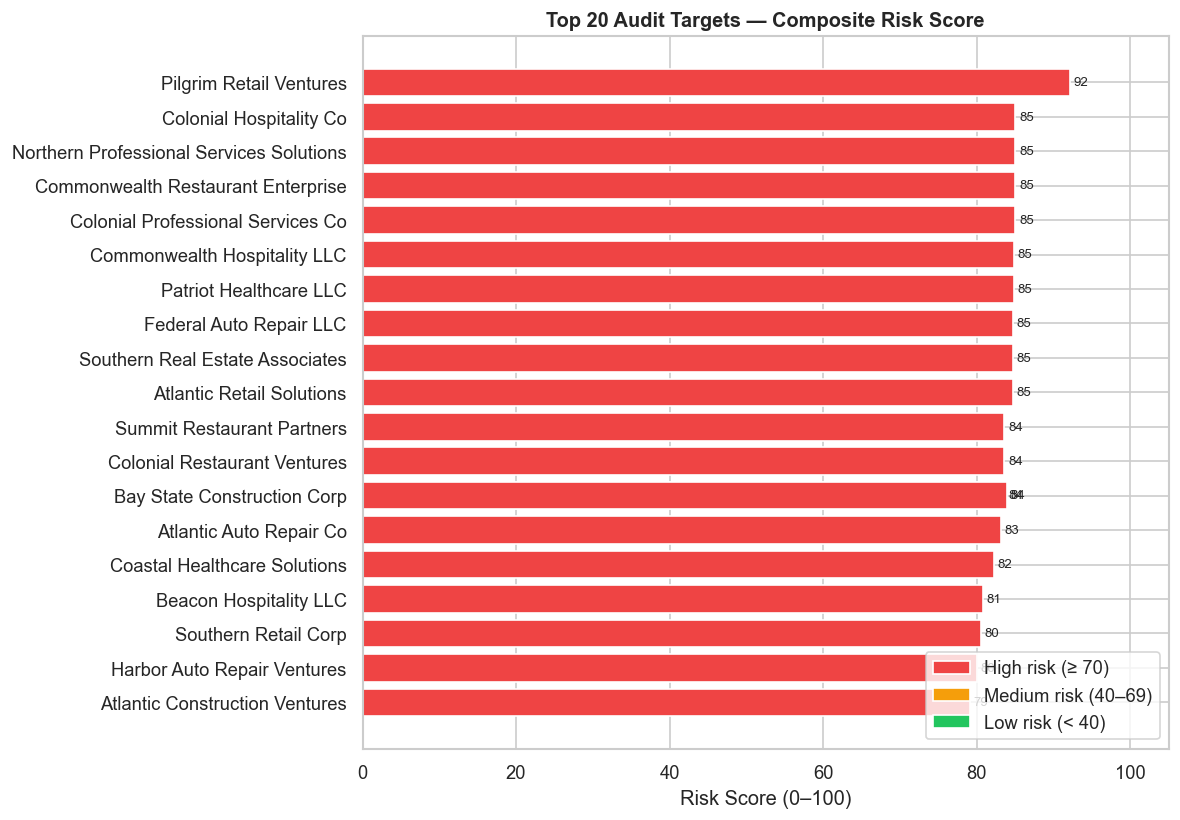

In [21]:
# ── Visualise top 20 by risk score ────────────────────────────────────────────
top20_plot = df_risk.nlargest(20, 'Risk_Score').copy()
if 'Business_Name' not in top20_plot.columns:
    top20_plot['Business_Name'] = top20_plot.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#ef4444' if s >= 70 else '#f59e0b' if s >= 40 else '#22c55e'
          for s in top20_plot['Risk_Score']]
bars = ax.barh(top20_plot['Business_Name'][::-1],
               top20_plot['Risk_Score'][::-1],
               color=colors[::-1], edgecolor='white')
for bar, score in zip(bars, top20_plot['Risk_Score'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{score:.0f}', va='center', fontsize=8)
ax.set_xlim(0, 105)
ax.set_title('Top 20 Audit Targets — Composite Risk Score', fontweight='bold')
ax.set_xlabel('Risk Score (0–100)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#ef4444', label='High risk (≥ 70)'),
                   Patch(facecolor='#f59e0b', label='Medium risk (40–69)'),
                   Patch(facecolor='#22c55e', label='Low risk (< 40)')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

---
## Section 5 — Key Findings & Recommendations

The following cells summarise the most important results for the audit selection
committee.  All figures are derived directly from the dataset — no assumptions
or external benchmarks have been used.

In [22]:
# ── Summary statistics ─────────────────────────────────────────────────────────
total_gap     = df_risk['Estimated_Tax_Gap'].sum()  if 'Estimated_Tax_Gap' in df_risk.columns else 0
top100_rec    = df_risk.nlargest(100, 'Risk_Score')['Estimated_Tax_Gap'].sum() \
                if 'Estimated_Tax_Gap' in df_risk.columns else 0
high_risk_n   = int((df_risk['Risk_Score'] >= 70).sum())
non_filer_n   = int(df_risk['Flag_LateOrNonFiler'].sum()) if 'Flag_LateOrNonFiler' in df_risk.columns else 0
repeat_n      = int(df_risk['Flag_RepeatOffender'].sum()) if 'Flag_RepeatOffender' in df_risk.columns else 0

# Top 3 industries by total tax gap
if 'Industry' in df_risk.columns and 'Estimated_Tax_Gap' in df_risk.columns:
    top_ind = (
        df_risk.groupby('Industry')['Estimated_Tax_Gap'].sum()
        .sort_values(ascending=False).head(3)
    )
else:
    top_ind = pd.Series(dtype=float)

# Top 3 cities by total tax gap
if 'City' in df_risk.columns and 'Estimated_Tax_Gap' in df_risk.columns:
    top_city = (
        df_risk.groupby('City')['Estimated_Tax_Gap'].sum()
        .sort_values(ascending=False).head(3)
    )
else:
    top_city = pd.Series(dtype=float)

print('=' * 60)
print('  EXECUTIVE SUMMARY — MA DOR TAX COMPLIANCE ANALYSIS')
print('=' * 60)
print(f'  Total records analysed   : {len(df_risk):,}')
print(f'  Total estimated tax gap  : ${total_gap:,.0f}')
print(f'  Est. recoverable (top 100): ${top100_rec:,.0f}')
print(f'  High-risk taxpayers       : {high_risk_n:,} (score ≥ 70)')
print(f'  Late / non-filers         : {non_filer_n:,}')
print(f'  Repeat offenders          : {repeat_n:,}')
print()
print('  TOP 3 INDUSTRIES BY TAX GAP')
for i, (ind, gap) in enumerate(top_ind.items(), 1):
    print(f'    {i}. {ind} — ${gap:,.0f}')
print()
print('  TOP 3 CITIES BY TAX GAP')
for i, (city, gap) in enumerate(top_city.items(), 1):
    print(f'    {i}. {city} — ${gap:,.0f}')
print('=' * 60)

  EXECUTIVE SUMMARY — MA DOR TAX COMPLIANCE ANALYSIS
  Total records analysed   : 3,000
  Total estimated tax gap  : $33,072,843
  Est. recoverable (top 100): $5,970,060
  High-risk taxpayers       : 50 (score ≥ 70)
  Late / non-filers         : 792
  Repeat offenders          : 23

  TOP 3 INDUSTRIES BY TAX GAP
    1. Construction — $6,365,137
    2. Manufacturing — $6,237,969
    3. Healthcare — $5,855,317

  TOP 3 CITIES BY TAX GAP
    1. Boston — $9,044,733
    2. Worcester — $4,283,571
    3. Springfield — $3,310,521


### Recommendations for the Audit Selection Committee

Based on the statistical analysis above, the following actions are recommended:

---

**1. Prioritise High-Risk Taxpayers in the Top Industries**

The industries identified above account for a disproportionate share of the total
estimated tax gap. Concentrating audit resources on businesses in these sectors
with a Risk Score above 70 offers the highest expected return per audit hour.

**2. Address the Non-Filer Backlog**

Non-filers represent a straightforward compliance failure — there is no ambiguity
about whether they owe tax.  Automated notices and escalation should be triggered
immediately for all current-year non-filers, especially those in the top-gap cities.

**3. Target Repeat Offenders Without Delay**

A taxpayer who was previously audited, found non-compliant, and is **still**
non-compliant has demonstrated that voluntary compliance has failed.  These cases
should be routed directly to enforcement rather than standard audit selection.

**4. Use Revenue Ratio as an Ongoing Monitoring Signal**

Any business reporting less than 60 % of its industry's average revenue is a
statistical outlier.  This threshold can be built into automated annual screening
without requiring analyst intervention for every case.

**5. Conduct Follow-Up Analysis on Top-Gap Cities**

The cities at the top of the tax-gap ranking may reflect either a high density of
non-compliant businesses or a small number of very large underpayments.  A
follow-up breakdown within each city will clarify which enforcement approach
(broad outreach vs. targeted large-case audits) is more appropriate.

---
*Analysis prepared using the MA DOR Tax Compliance Analytics tool.*  
*All scoring is based on publicly defensible statistical methods.*